# README: One-2-3-45: Single Image to 3D Mesh

Este notebook Colab implementa o modelo 'One-2-3-45' para gerar meshes 3D a partir de uma única imagem. Ele configura o ambiente, instala as dependências necessárias, baixa os checkpoints do modelo e executa a inferência para converter imagens 2D em modelos 3D, além de permitir a visualização dos resultados.

## Setup Inicial

**Requisitos de Runtime:**
- Runtime: `2025.07`
- GPU: A100 (ou compatível com alta RAM)

**Passos:**
1. Certifique-se de que o runtime do Colab está configurado conforme os requisitos (GPU A100, alta RAM).
2. Rode todas as células na ordem. Após a Célula 2, o Colab pode pedir para reiniciar o runtime — faça isso e continue a partir da Célula 3.

### Clonar Repositório
Para começar, clone o repositório do projeto. Se você já tem o código no seu Google Drive, pode pular esta etapa e ajustar o `PROJECT_DIR` na Célula 3.

```bash
!git clone https://github.com/your_username/One-2-3-45-master.git
# Substitua 'your_username' pelo nome de usuário ou organização do repositório original, se disponível.
```

## Fluxo do Notebook

### Célula 1 — Instalar PyTorch 2.1 + CUDA 12.1
Esta célula substitui a versão padrão do PyTorch no Colab por uma versão específica (2.1 + CUDA 12.1) que é compatível com a biblioteca `torchsparse` utilizada pelo projeto. Isso garante que todas as dependências funcionem corretamente juntas.

### Célula 2 — Instalar TorchSparse v1.4.0
Compila e instala a biblioteca `TorchSparse` versão 1.4.0 com suporte a CUDA. Este é um passo crucial para o desempenho do modelo. **IMPORTANTE:** Após a execução desta célula, se o Colab solicitar, **REINICIE O RUNTIME** (`Runtime > Restart runtime`) antes de prosseguir para a Célula 3.

### Célula 3 — Montar Drive e configurar projeto
Monta seu Google Drive no ambiente do Colab para acessar arquivos e salvar resultados. Você precisará **AJUSTAR O CAMINHO DA PASTA (`PROJECT_DIR`)** para onde o repositório 'One-2-3-45-master' está localizado no seu Drive. A célula também verifica a versão do PyTorch, CUDA e a GPU em uso.

### Célula 4 — Instalar dependências Python
Instala todas as bibliotecas Python adicionais necessárias para o projeto, como `albumentations`, `opencv-python`, `pytorch-lightning`, `diffusers`, `CLIP`, `segment-anything`, entre outras. Também inclui um patch para garantir a compatibilidade com a versão do PyTorch e NumPy.

### Célula 5 — Download dos Checkpoints (apenas primeira vez)
Esta célula gerencia o download dos checkpoints do modelo necessários para a inferência. Os arquivos são salvos no seu Google Drive (cerca de 10 GB). O script verifica se os checkpoints já existem e baixa apenas os que estiverem faltando, economizando tempo e banda.

### Célula 6 — Executar Inferência
Executa o processo de inferência para gerar um mesh 3D a partir de uma imagem de exemplo (`./demo/demo_examples/01_wild_hydrant.png`). O tempo estimado de processamento é de aproximadamente 2-3 minutos em uma GPU A100. O output é um arquivo `.ply` (mesh 3D).

### Célula 7 — Usar sua própria imagem
Permite que você processe suas próprias imagens localizadas na pasta `./inputs/edited/`. A célula itera sobre todas as imagens encontradas nessa pasta e executa a inferência 3D para cada uma, gerando os respectivos meshes. Se quiser usar uma imagem de outro local no seu Drive, use a **Opção B** na célula `a4pbp5xPwsiQ`, descomentando e ajustando o caminho.

### Célula 8 — Visualizar resultados
Esta seção contém duas células para visualizar os resultados:

- **Visualização de Meshes 3D (`qbJY06U_BBqv`):** Carrega e exibe os arquivos `.ply` gerados usando `plotly.graph_objects.Mesh3d`, permitindo uma inspeção interativa dos modelos 3D.
- **Visualização das Views (`Yel9KzgiwsiQ`):** Exibe as diferentes vistas 2D (views) geradas durante o processo de inferência, que são usadas para construir o modelo 3D. Isso ajuda a entender como o modelo 'enxerga' o objeto antes da reconstrução final.

### Célula Final — Copiar Meshes para a Pasta de Saída
Esta célula coleta todos os arquivos `mesh.ply` gerados nas pastas de experimento (`./exp/`) e os copia para uma pasta centralizada `./outputs/`. Isso facilita o acesso e a organização de todos os modelos 3D resultantes do processamento.

# One-2-3-45: Single Image to 3D Mesh
## Google Colab — Runtime 2025.07 + A100

**Requisitos:** Runtime `2025.07`, GPU A100, RAM Alta

**IMPORTANTE:** Rode TODAS as células na ordem, de cima para baixo. Após a Célula 2, o Colab vai pedir para reiniciar o runtime — faça isso e continue a partir da Célula 3.

---
## Célula 1 — Instalar PyTorch 2.1 + CUDA 12.1
Substitui o PyTorch padrão do Colab por uma versão compatível com torchsparse.

In [ ]:
!pip install "kornia==0.7.0"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 705.7/705.7 kB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 114.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 111.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 66.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 25.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Unins

In [ ]:
!pip install torch==2.1.0 torchvision==0.16.0 torchaudio==2.1.0 --index-url https://download.pytorch.org/whl/cu121
!pip install torch==2.0.1 torchvision==0.15.2 torchaudio==2.1.0 --index-url https://download.pytorch.org/whl/cu118

!pip install "numpy<2" "transformers==4.31.0" "diffusers==0.21.4" "huggingface_hub==0.25.0" "accelerate==0.25.0" "kornia==0.7.0"

Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.6
    Uninstalling numpy-2.4.6:
      Successfully uninstalled numpy-2.4.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
rembg 2.0.76 requires numpy<3.0.0,>=2.3.0, but you have numpy 1.26.4 which is incompatible.
cudf-cu12 25.2.1 requires numba<0.61.0a0,>=0.59.1, but you have numba 0.65.1 which is incompatible.
cuml-cu12 25.2.1 requires numba<0.61.0a0,>=0.59.1, but you have numba 0.65.1 which is incompatible.
d

---
## Célula 2 — Instalar TorchSparse v1.4.0
Compilação CUDA (~5-10 min). Após esta célula, **REINICIE O RUNTIME** se o Colab pedir, e continue na Célula 3.

In [ ]:
!sudo apt-get install -y -qq libsparsehash-dev
!FORCE_CUDA=1 pip install --no-cache-dir git+https://github.com/mit-han-lab/torchsparse.git@v1.4.0

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package libsparsehash-dev.
(Reading database ... 126281 files and directories currently installed.)
Preparing to unpack .../libsparsehash-dev_2.0.3-2_all.deb ...
Unpacking libsparsehash-dev (2.0.3-2) ...
Setting up libsparsehash-dev (2.0.3-2) ...
  Cloning https://github.com/mit-han-lab/torchsparse.git (to revision v1.4.0) to /tmp/pip-req-build-1_vmt53m
  Running command git clone --filter=blob:none --quiet https://github.com/mit-han-lab/torchsparse.git /tmp/pip-req-build-1_vmt53m
  Running command git checkout -q

---
## ⚠️ REINICIE O RUNTIME AQUI SE PEDIDO ⚠️
`Runtime > Restart runtime`, depois continue na Célula 3 abaixo.

---

## Célula 3 — Montar Drive e configurar projeto

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
# === AJUSTE O CAMINHO DA PASTA NO SEU DRIVE ===
PROJECT_DIR = '/Caminho-drive/One-2-3-45-master'
# ==============================================

assert os.path.exists(PROJECT_DIR), f"Pasta não encontrada: {PROJECT_DIR}"
os.chdir(PROJECT_DIR)
print(f"✓ Diretório: {os.getcwd()}")

# Verificar PyTorch e GPU
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.version.cuda}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Diretório: /content/drive/MyDrive/Ufma/ECP/CG/One-2-3-45-master
PyTorch: 2.1.0+cu121
CUDA: 12.1
GPU: NVIDIA A100-SXM4-80GB


## Célula 4 — Instalar dependências Python

In [ ]:
!pip install -q albumentations opencv-python imageio imageio-ffmpeg \
    pytorch-lightning omegaconf einops torch-fidelity \
    kornia torchmetrics fire rich plotly tqdm gdown \
    Pillow scikit-image scikit-learn scipy matplotlib PyYAML loguru \
    tensorboardX multipledispatch packaging transforms3d trimesh yacs \
    rembg onnxruntime-gpu onnx pyhocon icecream PyMCubes ninja \
    datasets webdataset dl_ext

!pip install -q git+https://github.com/openai/CLIP.git
!pip install -q git+https://github.com/facebookresearch/segment-anything.git
!pip install -q inplace-abn

# Taming Transformers (clone direto, pip não funciona em Python 3.11+)
!git clone -q https://github.com/CompVis/taming-transformers.git /content/taming-transformers 2>/dev/null || true

# Forçar numpy<2 (dependências acima podem ter puxado numpy 2.x)
!pip install -q "numpy<2"

# Patch SAM para compatibilidade com PyTorch 2.1 + numpy
!sed -i 's/input_image_torch = torch.as_tensor(input_image, device=self.device)/input_image_torch = torch.from_numpy(input_image.copy()).to(self.device)/' /usr/local/lib/python3.11/dist-packages/segment_anything/predictor.py

print("\n✓ Dependências instaladas!")

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
rembg 2.0.76 requires numpy<3.0.0,>=2.3.0, but you have numpy 1.26.4 which is incompatible.
cudf-cu12 25.2.1 requires numba<0.61.0a0,>=0.59.1, but you have numba 0.65.1 which is incompatible.
cuml-cu12 25.2.1 requires numba<0.61.0a0,>=0.59.1, but you have numba 0.65.1 which is incompatible.
dask-cuda 25.2.0 requires numba<0.61.0a0,>=0.59.1, but you have numba 0.65.1 which is incompatible.
distributed-ucxx-cu12 0.42.0 requires numba<0.61.0a0,>=0.59.1, but you have numba 0.65.1 which is incompatible.
gradio 5.31.0 requires huggingface-hub>=0.28.1, but you have huggingface-hub 0.25.0 which is incompatible.
gradio

## Célula 5 — Download dos Checkpoints (apenas primeira vez)
Os checkpoints ficam salvos no Drive (~10 GB). Só baixa o que estiver faltando.

In [ ]:
import os

checkpoints = [
    "sam_vit_h_4b8939.pth",
    "zero123-xl.ckpt",
    "elevation_estimate/utils/weights/indoor_ds_new.ckpt",
    "reconstruction/exp/lod0/checkpoints/ckpt_215000.pth"
]

missing = [ckpt for ckpt in checkpoints if not os.path.exists(ckpt)]

if missing:
    print(f"⏳ Baixando {len(missing)} checkpoints...")
    !python download_ckpt.py
    print("\n✓ Download concluído!")
else:
    print("✓ Todos os checkpoints já estão no Drive.")

✓ Todos os checkpoints já estão no Drive.


## Célula 6 — Executar Inferência
Gera um mesh 3D a partir de uma imagem. Tempo estimado: ~2-3 min na A100.

In [ ]:
# Usar imagem de exemplo do repositório
!PYTHONPATH=/content/taming-transformers:$PYTHONPATH python run.py \
    --img_path ./demo/demo_examples/01_wild_hydrant.png \
    --half_precision

2026-06-18 12:39:19.618572: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781786359.640994   28411 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781786359.647596   28411 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
Loading SAM for preprocessing...
SAM Time: 0.757s
SAM unloaded. Memory freed.
Loading Zero123-XL...
Instantiating LatentDiffusion...
Loading model from zero123-xl.ckpt
Global Step: 122000
LatentDiffusion: Running in eps-prediction mode
DiffusionWrapper has 859.53 M params.
Keeping EMAs of 688.
making attention of type 'vanilla' with 512 in_channels
Working with z of shape (1, 4, 32, 32) = 4096 dimensions.
making attention of type 'va

## Célula 7 — Usar sua própria imagem

In [ ]:
import glob, subprocess, sys

imgs = sorted(glob.glob("./inputs/edited/*.*"))


print(f"Imagens encontradas: {len(imgs)}")
for img in imgs:
    print(f"  - {img}")

for img in imgs:
    print(f"\n{'='*50}")
    print(f"Processando: {img}")
    print(f"{'='*50}", flush=True)
    proc = subprocess.Popen(
        f'PYTHONPATH=/content/taming-transformers:$PYTHONPATH python -u run.py --img_path "{img}" --half_precision',
        shell=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True
    )
    for line in proc.stdout:
        print(line, end='', flush=True)
    proc.wait()
    if proc.returncode != 0:
        print(f"⚠ Erro ao processar {img}")

print(f"\n✓ Processamento concluído!")




Imagens encontradas: 4
  - ./inputs/edited/busto-edited.png
  - ./inputs/edited/canhao-edited.png
  - ./inputs/edited/leao-edited.png
  - ./inputs/edited/poste-edited.png

Processando: ./inputs/edited/busto-edited.png
2026-06-18 12:47:47.317871: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781786867.340157   30859 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781786867.347219   30859 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
Loading SAM for preprocessing...
SAM Time: 0.746s
SAM unloaded. Memory freed.
Loading Zero123-XL...
Instantiating LatentDiffusion...
Loading model from zero123-xl.ckpt
Global Step: 122000
LatentDiffusion: Running in eps

In [ ]:
# Opção B: Imagem do Drive
# Descomente e ajuste o caminho:
# !PYTHONPATH=/content/taming-transformers:$PYTHONPATH python run.py \
#     --img_path /content/drive/MyDrive/minha_imagem.png --half_precision

## Célula 8 — Visualizar resultados

In [ ]:
import glob, os
import trimesh
import plotly.graph_objects as go
from IPython.display import display, HTML

mesh_files = sorted(glob.glob("./exp/*/mesh.ply"), key=os.path.getmtime)
print(f"Meshes gerados: {len(mesh_files)}\n")

for mesh_path in mesh_files:
    name = os.path.basename(os.path.dirname(mesh_path))
    size_mb = os.path.getsize(mesh_path) / 1e6
    print(f"{'='*40}")
    print(f"{name} ({size_mb:.1f} MB)")
    print(f"{'='*40}")

    mesh = trimesh.load_mesh(mesh_path)
    vertices = mesh.vertices
    faces = mesh.faces

    # Cores por vértice
    if hasattr(mesh.visual, 'vertex_colors') and mesh.visual.vertex_colors is not None:
        colors = mesh.visual.vertex_colors[:, :3]
        fig = go.Figure(data=[go.Mesh3d(
            x=vertices[:, 0], y=vertices[:, 1], z=vertices[:, 2],
            i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
            vertexcolor=colors, opacity=1.0
        )])
    else:
        fig = go.Figure(data=[go.Mesh3d(
            x=vertices[:, 0], y=vertices[:, 1], z=vertices[:, 2],
            i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
            color='lightblue', opacity=0.9
        )])

    fig.update_layout(
        title=name,
        scene=dict(aspectmode='data'),
        height=500
    )
    fig.show()

Output hidden; open in https://colab.research.google.com to view.


stage1_8 — 8 views


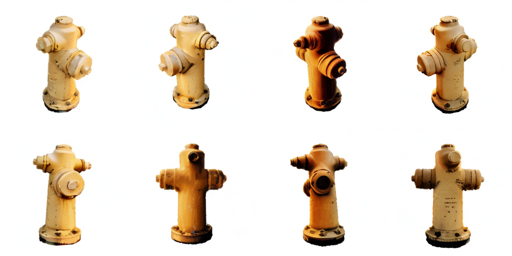


stage1_8 — 8 views


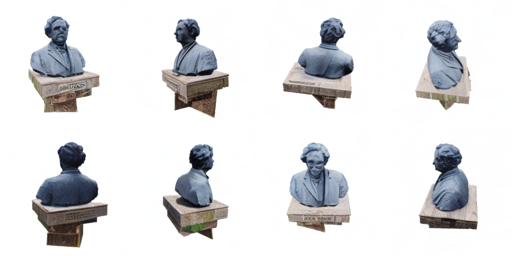


stage1_8 — 12 views


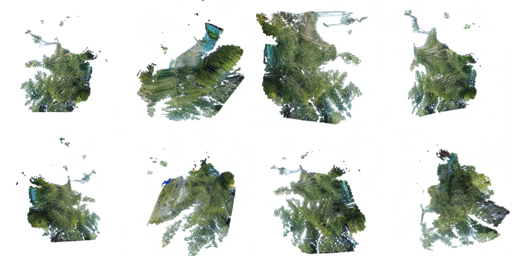


stage1_8 — 8 views


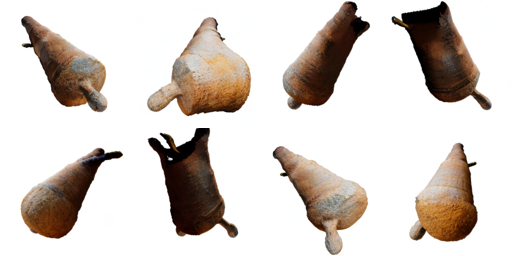


stage1_8 — 8 views


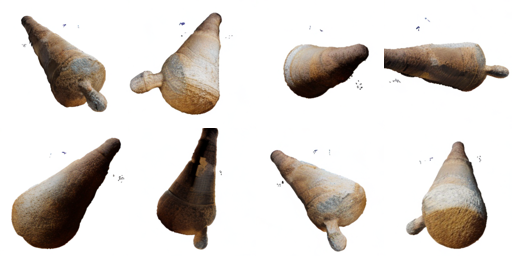


stage1_8 — 8 views


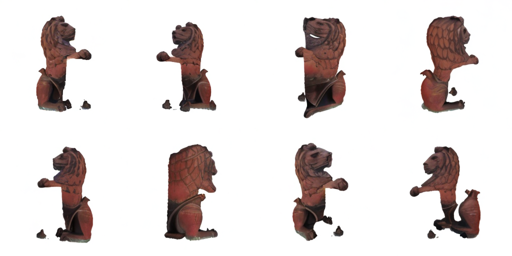


stage1_8 — 8 views


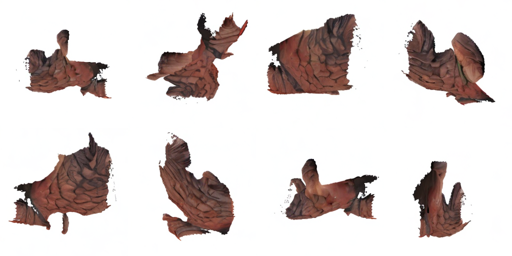


stage1_8 — 8 views


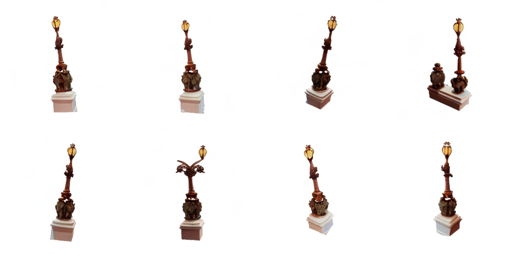


stage1_8 — 8 views


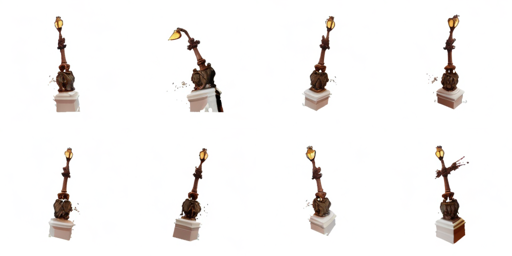

In [ ]:
import glob, os
from PIL import Image
from IPython.display import display

exp_dirs = sorted(glob.glob("./exp/*/stage1_8/"))

for stage1_dir in exp_dirs:
    name = os.path.basename(os.path.dirname(stage1_dir))
    imgs = sorted(glob.glob(os.path.join(stage1_dir, "*.png")))
    if imgs:
        print(f"\n{'='*40}")
        print(f"{name} — {len(imgs)} views")
        print(f"{'='*40}")
        pil_imgs = [Image.open(p).resize((128, 128)) for p in imgs[:8]]
        grid_w = min(4, len(pil_imgs))
        grid_h = (len(pil_imgs) + grid_w - 1) // grid_w
        grid = Image.new('RGB', (128*grid_w, 128*grid_h))
        for i, img in enumerate(pil_imgs):
            grid.paste(img, (128*(i%grid_w), 128*(i//grid_w)))
        display(grid)

In [ ]:
import glob, os, shutil

output_dir = './outputs'
os.makedirs(output_dir, exist_ok=True)

mesh_files = glob.glob("./exp/*/mesh.ply")
for mesh_path in mesh_files:
    name = os.path.basename(os.path.dirname(mesh_path)) + '_mesh.ply'
    shutil.copy2(mesh_path, os.path.join(output_dir, name))

print(f"✓ {len(mesh_files)} meshes copiados para {output_dir}/")
print("\nArquivos:")
for f in sorted(os.listdir(output_dir)):
    if f.endswith('.ply'):
        print(f"  {f}")

✓ 9 meshes copiados para ./outputs/

Arquivos:
  01_wild_hydrant_mesh.ply
  busto-edited_mesh.ply
  busto_mesh.ply
  canhao-edited_mesh.ply
  canhao_mesh.ply
  leao-edited_mesh.ply
  leao_mesh.ply
  poste-edited_mesh.ply
  poste_mesh.ply


In [ ]:
!pip install -q plotly
import trimesh
import plotly.graph_objects as go
import numpy as np

mesh = trimesh.load_mesh(mesh_path)
vertices = mesh.vertices
faces = mesh.faces

fig = go.Figure(data=[go.Mesh3d(
    x=vertices[:, 0], y=vertices[:, 1], z=vertices[:, 2],
    i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
    color='lightblue', opacity=0.9
)])
fig.update_layout(scene=dict(aspectmode='data'))
fig.show()

In [ ]:
import trimesh
import plotly.graph_objects as go
import numpy as np

mesh = trimesh.load_mesh(mesh_path)
vertices = mesh.vertices
faces = mesh.faces

# Extrair cores dos vértices (RGBA -> RGB normalizado)
if mesh.visual.vertex_colors is not None:
    colors = mesh.visual.vertex_colors[:, :3]  # RGB
    # Converter para string de cor por vértice
    vertex_colors = ['rgb({},{},{})'.format(r, g, b) for r, g, b in colors]

    fig = go.Figure(data=[go.Mesh3d(
        x=vertices[:, 0], y=vertices[:, 1], z=vertices[:, 2],
        i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
        vertexcolor=colors,
        opacity=1.0
    )])
else:
    fig = go.Figure(data=[go.Mesh3d(
        x=vertices[:, 0], y=vertices[:, 1], z=vertices[:, 2],
        i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
        color='lightblue', opacity=0.9
    )])

fig.update_layout(scene=dict(aspectmode='data'))
fig.show()